In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 18.3 MB/s eta 0:00:00


In [3]:
import os
import re
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
    StopWordRemoverFactory
)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
BASE_DIR = '/content/drive/MyDrive/NLP_Final_Project_Final'
DATA_DIR = f'{BASE_DIR}/data/splits'
MODEL_DIR = f'{BASE_DIR}/models/classical'
ARTIFACT_DIR = f'{BASE_DIR}/artifacts/classical'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("BASE_DIR    :", BASE_DIR)
print("DATA_DIR    :", DATA_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

df_train = pd.read_csv(f'{DATA_DIR}/train_data.csv')
df_val = pd.read_csv(f'{DATA_DIR}/val_data.csv')
df_test = pd.read_csv(f'{DATA_DIR}/test_data.csv')

print("\nUkuran dataset:")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

required_cols = ['judul', 'text_clean', 'sentimen', 'label_id']

for dataset_name, dataframe in [
    ('train', df_train),
    ('validation', df_val),
    ('test', df_test)
]:
    for col in required_cols:
        if col not in dataframe.columns:
            raise ValueError(
                f"Kolom '{col}' tidak ditemukan pada data {dataset_name}."
            )

print("\nComplete")

BASE_DIR    : /content/drive/MyDrive/NLP_Final_Project_Final
DATA_DIR    : /content/drive/MyDrive/NLP_Final_Project_Final/data/splits
MODEL_DIR   : /content/drive/MyDrive/NLP_Final_Project_Final/models/classical
ARTIFACT_DIR: /content/drive/MyDrive/NLP_Final_Project_Final/artifacts/classical

Ukuran dataset:
Train: (7797, 4)
Val  : (975, 4)
Test : (975, 4)

Complete


In [5]:
stop_factory = StopWordRemoverFactory()
stopwords_default = set(stop_factory.get_stop_words())

keep_words = {
    'tidak',
    'bukan',
    'belum',
    'jangan',
    'kurang'
}

custom_stopwords = stopwords_default - keep_words

stemmer = StemmerFactory().create_stemmer()


def remove_stopwords_custom(text):
    tokens = str(text).split()
    tokens = [
        token for token in tokens
        if token not in custom_stopwords
    ]
    return ' '.join(tokens)


def preprocess_classical(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = remove_stopwords_custom(text)
    text = stemmer.stem(text)

    return text

df_train['text_classical'] = (
    df_train['text_clean']
    .fillna('')
    .apply(preprocess_classical)
)

df_val['text_classical'] = (
    df_val['text_clean']
    .fillna('')
    .apply(preprocess_classical)
)

df_test['text_classical'] = (
    df_test['text_clean']
    .fillna('')
    .apply(preprocess_classical)
)

print("\nPreprocessing selesai.")


Preprocessing selesai.


In [6]:
preview_classical = df_train[
    ['judul', 'text_clean', 'text_classical', 'sentimen']
].sample(
    n=10,
    random_state=42
).reset_index(drop=True)

display(preview_classical)

preview_classical.to_csv(
    f'{ARTIFACT_DIR}/preprocessing_preview_classical.csv',
    index=False
)

,judul,text_clean,text_classical,sentimen
0,"Trump Tunda Perang Dagang, Dolar Turun ke Rp 1...","trump tunda perang dagang, dolar turun ke rupi...",trump tunda perang dagang dolar turun rupiah 1...,positif
1,"Terungkap, Jokowi Ketar-ketir Waktu Dolar AS S...","terungkap, jokowi ketar-ketir waktu dolar as s...",ungkap jokowi ketar tir waktu dolar as sempat ...,negatif
2,Krom Bank Andalkan Modal Dulu Buat Salurkan Kr...,krom bank andalkan modal dulu buat salurkan kr...,krom bank andal modal dulu buat salur kredit,netral
3,"Robert Kiyosaki Ingatkan Nasib Buruk Dolar, Ka...","robert kiyosaki ingatkan nasib buruk dolar, ka...",robert kiyosaki ingat nasib buruk dolar kasih ...,netral
4,"Elon Musk Jadi Musuh Warga AS, Tesla Kena Boik...","elon musk jadi musuh warga as, tesla kena boik...",elon musk jadi musuh warga as tesla kena boiko...,negatif
5,"Bank Mega Syariah Cetak Laba Rp253,19 M Sepanj...","bank mega syariah cetak laba rupiah 253,19 m s...",bank mega syariah cetak laba rupiah 253 19 m p...,positif
6,"Investor Pelototi Tanda-Tanda dari AS, Harga M...","investor pelototi tanda-tanda dari as, harga m...",investor pelotot tanda tanda as harga minyak c...,netral
7,Emiten Suami Puan (CBRE) Targetkan Lonjakan Pe...,emiten suami puan (cbre) targetkan lonjakan pe...,emiten suami puan cbre target lonjak dapat 3 k...,positif
8,"Jensen Huang Lego Besar-Besaran, Saham Nvidia ...","jensen huang lego besar-besaran, saham nvidia ...",jensen huang lego besar besar saham nvidia ambruk,negatif
9,Alasan Danantara Angkat Tokoh Global Jadi Dewa...,alasan danantara angkat tokoh global jadi dewa...,alas danantara angkat tokoh global jadi dewan ...,netral


In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

tfidf_start_time = time.time()

X_train = tfidf.fit_transform(df_train['text_classical'])
X_val = tfidf.transform(df_val['text_classical'])
X_test = tfidf.transform(df_test['text_classical'])

tfidf_time_sec = time.time() - tfidf_start_time

y_train = df_train['label_id'].astype(int).values
y_val = df_val['label_id'].astype(int).values
y_test = df_test['label_id'].astype(int).values

print("\nUkuran matriks TF-IDF:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nJumlah fitur TF-IDF:", len(tfidf.get_feature_names_out()))
print(f"Waktu TF-IDF: {tfidf_time_sec:.4f} detik")


Ukuran matriks TF-IDF:
X_train: (7797, 10867)
X_val  : (975, 10867)
X_test : (975, 10867)

Jumlah fitur TF-IDF: 10867
Waktu TF-IDF: 0.2235 detik


In [8]:
label_names = ['negatif', 'netral', 'positif']
label_mapping = {
    0: 'negatif',
    1: 'netral',
    2: 'positif'
}


def compute_metrics_full(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0
        )
    )

    return {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted
    }


def plot_and_save_confusion_matrix(
    cm,
    labels,
    title,
    save_path
):

    plt.figure(figsize=(6, 5))
    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=plt.cm.Blues
    )

    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                horizontalalignment='center',
                verticalalignment='center',
                color='white' if cm[i, j] > threshold else 'black'
            )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    plt.savefig(
        save_path,
        bbox_inches='tight',
        dpi=150
    )

    plt.show()
    plt.close()

TUNING SVM

In [9]:
svm_grid = [0.25, 0.5, 1.0, 2.0, 4.0]

best_svm_c = None
best_svm_f1 = -1

svm_tuning_results = []

print("\n" + "=" * 60)
print("SVM HYPERPARAMETER TUNING")
print("=" * 60)

for c in svm_grid:

    candidate_model = LinearSVC(
        C=c,
        class_weight='balanced',
        random_state=42,
        max_iter=10000
    )

    candidate_model.fit(X_train, y_train)

    val_pred = candidate_model.predict(X_val)

    val_f1 = f1_score(
        y_val,
        val_pred,
        average='macro',
        zero_division=0
    )

    svm_tuning_results.append({
        'C': c,
        'validation_macro_f1': val_f1
    })

    print(
        f"C={c} | "
        f"Validation Macro-F1={val_f1:.4f}"
    )

    if val_f1 > best_svm_f1:
        best_svm_f1 = val_f1
        best_svm_c = c

print("\nBest SVM C:", best_svm_c)
print("Best SVM Validation Macro-F1:", best_svm_f1)

svm_tuning_df = pd.DataFrame(svm_tuning_results)

svm_tuning_df.to_csv(
    f'{ARTIFACT_DIR}/svm_tuning_results.csv',
    index=False
)

display(svm_tuning_df)


SVM HYPERPARAMETER TUNING
C=0.25 | Validation Macro-F1=0.8276
C=0.5 | Validation Macro-F1=0.8315
C=1.0 | Validation Macro-F1=0.8314
C=2.0 | Validation Macro-F1=0.8306
C=4.0 | Validation Macro-F1=0.8255

Best SVM C: 0.5
Best SVM Validation Macro-F1: 0.8315497799846335


,C,validation_macro_f1
0,0.25,0.827646
1,0.50,0.831550
2,1.00,0.831365
3,2.00,0.830643
4,4.00,0.825461


TUNING RF

In [10]:
rf_grid = [
    {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_split': 2
    },
    {
        'n_estimators': 200,
        'max_depth': None,
        'min_samples_split': 2
    },
    {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 2
    },
    {
        'n_estimators': 300,
        'max_depth': 20,
        'min_samples_split': 5
    }
]

best_rf_params = None
best_rf_f1 = -1

rf_tuning_results = []

print("\n" + "=" * 60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 60)

for params in rf_grid:

    candidate_model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    candidate_model.fit(X_train, y_train)

    val_pred = candidate_model.predict(X_val)

    val_f1 = f1_score(
        y_val,
        val_pred,
        average='macro',
        zero_division=0
    )

    rf_tuning_results.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'validation_macro_f1': val_f1
    })

    print(
        f"{params} | "
        f"Validation Macro-F1={val_f1:.4f}"
    )

    if val_f1 > best_rf_f1:
        best_rf_f1 = val_f1
        best_rf_params = params.copy()

print("\nBest Random Forest Params:", best_rf_params)
print("Best Random Forest Validation Macro-F1:", best_rf_f1)

rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df.to_csv(
    f'{ARTIFACT_DIR}/rf_tuning_results.csv',
    index=False
)

display(rf_tuning_df)


RANDOM FOREST HYPERPARAMETER TUNING
{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | Validation Macro-F1=0.7858
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2} | Validation Macro-F1=0.7898
{'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2} | Validation Macro-F1=0.7437
{'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | Validation Macro-F1=0.7441

Best Random Forest Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
Best Random Forest Validation Macro-F1: 0.789833859331654


,n_estimators,max_depth,min_samples_split,validation_macro_f1
0,100,NaN,2,0.785822
1,200,NaN,2,0.789834
2,200,20.0,2,0.743708
3,300,20.0,5,0.744080


In [11]:
svm_final = LinearSVC(
    C=best_svm_c,
    class_weight='balanced',
    random_state=42,
    max_iter=10000
)

svm_start_time = time.time()

svm_final.fit(X_train, y_train)

svm_train_time_sec = time.time() - svm_start_time

print(
    f"\nSVM final training time: "
    f"{svm_train_time_sec:.4f} detik"
)


SVM final training time: 0.0791 detik


In [12]:
rf_final = RandomForestClassifier(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_start_time = time.time()

rf_final.fit(X_train, y_train)

rf_train_time_sec = time.time() - rf_start_time

print(
    f"Random Forest final training time: "
    f"{rf_train_time_sec:.4f} detik"
)

Random Forest final training time: 31.3764 detik



FINAL TEST RESULTS - SVM
SVM Metrics:
accuracy: 0.8256
precision_macro: 0.8229
recall_macro: 0.8257
f1_macro: 0.8242
precision_weighted: 0.8262
recall_weighted: 0.8256
f1_weighted: 0.8258

SVM Classification Report:
              precision    recall  f1-score   support

     negatif       0.79      0.82      0.80       256
      netral       0.84      0.82      0.83       430
     positif       0.85      0.84      0.84       289

    accuracy                           0.83       975
   macro avg       0.82      0.83      0.82       975
weighted avg       0.83      0.83      0.83       975



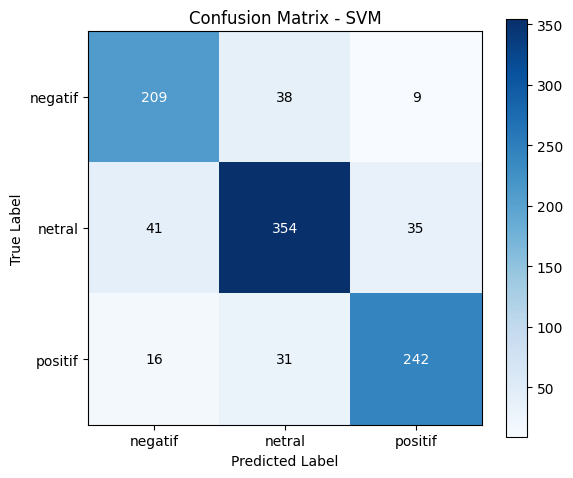

In [13]:
svm_pred = svm_final.predict(X_test)

svm_metrics = compute_metrics_full(
    y_test,
    svm_pred
)

svm_cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=[0, 1, 2]
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS - SVM")
print("=" * 60)

print("SVM Metrics:")
for metric_name, metric_value in svm_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nSVM Classification Report:")
print(
    classification_report(
        y_test,
        svm_pred,
        labels=[0, 1, 2],
        target_names=label_names,
        zero_division=0
    )
)

plot_and_save_confusion_matrix(
    svm_cm,
    label_names,
    title='Confusion Matrix - SVM',
    save_path=f'{ARTIFACT_DIR}/confusion_matrix_svm.png'
)


FINAL TEST RESULTS - RANDOM FOREST
Random Forest Metrics:
accuracy: 0.7877
precision_macro: 0.7934
recall_macro: 0.7739
f1_macro: 0.7812
precision_weighted: 0.7895
recall_weighted: 0.7877
f1_weighted: 0.7864

Random Forest Classification Report:
              precision    recall  f1-score   support

     negatif       0.81      0.69      0.75       256
      netral       0.77      0.85      0.81       430
     positif       0.79      0.79      0.79       289

    accuracy                           0.79       975
   macro avg       0.79      0.77      0.78       975
weighted avg       0.79      0.79      0.79       975



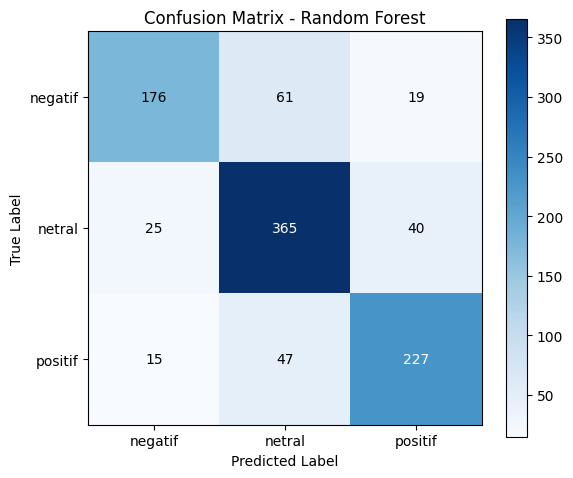

In [14]:
rf_pred = rf_final.predict(X_test)

rf_metrics = compute_metrics_full(
    y_test,
    rf_pred
)

rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=[0, 1, 2]
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS - RANDOM FOREST")
print("=" * 60)

print("Random Forest Metrics:")
for metric_name, metric_value in rf_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=label_names,
        zero_division=0
    )
)

plot_and_save_confusion_matrix(
    rf_cm,
    label_names,
    title='Confusion Matrix - Random Forest',
    save_path=f'{ARTIFACT_DIR}/confusion_matrix_rf.png'
)

In [15]:
joblib.dump(
    svm_final,
    f'{MODEL_DIR}/svm_model.pkl'
)

joblib.dump(
    rf_final,
    f'{MODEL_DIR}/rf_model.pkl'
)

joblib.dump(
    tfidf,
    f'{MODEL_DIR}/tfidf_vectorizer.pkl'
)

print("\nModel berhasil disimpan:")
print(f"- {MODEL_DIR}/svm_model.pkl")
print(f"- {MODEL_DIR}/rf_model.pkl")
print(f"- {MODEL_DIR}/tfidf_vectorizer.pkl")


Model berhasil disimpan:
- /content/drive/MyDrive/NLP_Final_Project_Final/models/classical/svm_model.pkl
- /content/drive/MyDrive/NLP_Final_Project_Final/models/classical/rf_model.pkl
- /content/drive/MyDrive/NLP_Final_Project_Final/models/classical/tfidf_vectorizer.pkl


In [16]:
svm_pred_df = df_test[
    ['judul', 'text_clean', 'sentimen', 'label_id']
].copy()

svm_pred_df['pred_label_id'] = svm_pred
svm_pred_df['pred_sentimen'] = (
    svm_pred_df['pred_label_id']
    .map(label_mapping)
)

svm_pred_df['is_correct'] = (
    svm_pred_df['label_id'] ==
    svm_pred_df['pred_label_id']
)

svm_pred_df.to_csv(
    f'{ARTIFACT_DIR}/svm_test_predictions.csv',
    index=False
)

In [17]:
rf_pred_df = df_test[
    ['judul', 'text_clean', 'sentimen', 'label_id']
].copy()

rf_pred_df['pred_label_id'] = rf_pred
rf_pred_df['pred_sentimen'] = (
    rf_pred_df['pred_label_id']
    .map(label_mapping)
)

rf_pred_df['is_correct'] = (
    rf_pred_df['label_id'] ==
    rf_pred_df['pred_label_id']
)

rf_pred_df.to_csv(
    f'{ARTIFACT_DIR}/rf_test_predictions.csv',
    index=False
)

print("\nFile prediksi berhasil disimpan:")
print(f"- {ARTIFACT_DIR}/svm_test_predictions.csv")
print(f"- {ARTIFACT_DIR}/rf_test_predictions.csv")


File prediksi berhasil disimpan:
- /content/drive/MyDrive/NLP_Final_Project_Final/artifacts/classical/svm_test_predictions.csv
- /content/drive/MyDrive/NLP_Final_Project_Final/artifacts/classical/rf_test_predictions.csv


In [18]:
svm_report_df = pd.DataFrame(
    classification_report(
        y_test,
        svm_pred,
        labels=[0, 1, 2],
        target_names=label_names,
        zero_division=0,
        output_dict=True
    )
).transpose()

svm_report_df.to_csv(
    f'{ARTIFACT_DIR}/svm_classification_report.csv'
)

rf_report_df = pd.DataFrame(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=label_names,
        zero_division=0,
        output_dict=True
    )
).transpose()

rf_report_df.to_csv(
    f'{ARTIFACT_DIR}/rf_classification_report.csv'
)

In [19]:
summary_df = pd.DataFrame([
    {
        'model': 'SVM',
        'best_params': str({
            'C': best_svm_c
        }),
        'validation_f1_macro': best_svm_f1,
        'accuracy': svm_metrics['accuracy'],
        'precision_macro': svm_metrics['precision_macro'],
        'recall_macro': svm_metrics['recall_macro'],
        'f1_macro': svm_metrics['f1_macro'],
        'precision_weighted': svm_metrics['precision_weighted'],
        'recall_weighted': svm_metrics['recall_weighted'],
        'f1_weighted': svm_metrics['f1_weighted'],
        'train_time_sec': svm_train_time_sec,
        'tfidf_time_sec': tfidf_time_sec
    },
    {
        'model': 'RandomForest',
        'best_params': str(best_rf_params),
        'validation_f1_macro': best_rf_f1,
        'accuracy': rf_metrics['accuracy'],
        'precision_macro': rf_metrics['precision_macro'],
        'recall_macro': rf_metrics['recall_macro'],
        'f1_macro': rf_metrics['f1_macro'],
        'precision_weighted': rf_metrics['precision_weighted'],
        'recall_weighted': rf_metrics['recall_weighted'],
        'f1_weighted': rf_metrics['f1_weighted'],
        'train_time_sec': rf_train_time_sec,
        'tfidf_time_sec': tfidf_time_sec
    }
])

summary_df.to_csv(
    f'{ARTIFACT_DIR}/classical_metrics_summary.csv',
    index=False
)

print("\nRingkasan hasil model klasik:")
display(summary_df)


Ringkasan hasil model klasik:


,model,best_params,validation_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_time_sec,tfidf_time_sec
0,SVM,{'C': 0.5},0.831550,0.825641,0.822916,0.825677,0.824172,0.826194,0.825641,0.825809,0.079073,0.223483
1,RandomForest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.789834,0.787692,0.793397,0.773935,0.781248,0.789530,0.787692,0.786378,31.376426,0.223483


In [20]:
print("\nContoh prediksi benar SVM:")
display(
    svm_pred_df[
        svm_pred_df['is_correct'] == True
    ].sample(
        n=min(
            5,
            svm_pred_df['is_correct'].sum()
        ),
        random_state=42
    )
)

print("\nContoh prediksi salah SVM:")
display(
    svm_pred_df[
        svm_pred_df['is_correct'] == False
    ].sample(
        n=min(
            5,
            (~svm_pred_df['is_correct']).sum()
        ),
        random_state=42
    )
)

print("\nContoh prediksi benar Random Forest:")
display(
    rf_pred_df[
        rf_pred_df['is_correct'] == True
    ].sample(
        n=min(
            5,
            rf_pred_df['is_correct'].sum()
        ),
        random_state=42
    )
)

print("\nContoh prediksi salah Random Forest:")
display(
    rf_pred_df[
        rf_pred_df['is_correct'] == False
    ].sample(
        n=min(
            5,
            (~rf_pred_df['is_correct']).sum()
        ),
        random_state=42
    )
)


Contoh prediksi benar SVM:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
235,Techno9 (NINE) Siap Diakuisisi Perusahaan Tamb...,techno9 (nine) siap diakuisisi perusahaan tamb...,netral,1,1,netral,True
869,"Bursa Kebakaran, Harta Konglomerat Dunia Lenya...","bursa kebakaran, harta konglomerat dunia lenya...",negatif,0,0,negatif,True
202,"Indocement (INTP) Buyback Saham Rp 565,05 Mili...","indocement (intp) buyback saham rupiah 565,05 ...",positif,2,2,positif,True
629,Orang-Orang Ini Jadi Konglomerat Berkat Kripto,orang-orang ini jadi konglomerat berkat kripto,netral,1,1,netral,True
644,Prabowo Terima Bos New Development Bank di Ist...,prabowo terima bos new development bank di ist...,netral,1,1,netral,True



Contoh prediksi salah SVM:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
801,"Starbucks, Nike & Boeing Tak Menarik Lagi di M...","starbucks, nike & boeing tak menarik lagi di m...",negatif,0,1,netral,False
187,Sandiaga Sebut Ini Jadi Penyebab Harta Turun R...,sandiaga sebut ini jadi penyebab harta turun r...,netral,1,2,positif,False
691,"Fee Based Income BNI (BBNI) Tembus Rp10,9 T, T...","fee based income bni (bbni) tembus rupiah 10,9...",netral,1,2,positif,False
185,"Ekonomi Dunia Suram di Depan Mata, Ini Tiga As...","ekonomi dunia suram di depan mata, ini tiga as...",negatif,0,1,netral,False
822,Sumber Global Energy (SGER) Tegaskan Tudingan ...,sumber global energy (sger) tegaskan tudingan ...,netral,1,0,negatif,False



Contoh prediksi benar Random Forest:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
846,Nama di BI Checking atau SLIK OJK Bermasalah? ...,nama di bi checking atau slik ojk bermasalah? ...,netral,1,1,netral,True
407,Koin Kripto Hawk Tuah Anjlok 91% Setelah Melun...,koin kripto hawk tuah anjlok 91 persen setelah...,negatif,0,0,negatif,True
790,"Sederet Upaya Harita (NCKL) Tangani Limbah, in...","sederet upaya harita (nckl) tangani limbah, in...",netral,1,1,netral,True
874,OJK Perkuat Industri Perusahaan Pembiayaan Pak...,ojk perkuat industri perusahaan pembiayaan pak...,positif,2,2,positif,True
591,Pertamina Geothermal (PGEO) Mau Gelar MESOP Be...,pertamina geothermal (pgeo) mau gelar mesop be...,netral,1,1,netral,True



Contoh prediksi salah Random Forest:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
771,Survei LPS: Masyarakat Makin Gencar Menabung J...,survei lps: masyarakat makin gencar menabung j...,netral,1,0,negatif,False
49,"44 Pinjol Diduga Kartel Soal Bunga, Bulan Mei ...","44 pinjol diduga kartel soal bunga, bulan mei ...",negatif,0,1,netral,False
371,OJK Bekukan Aktivitas Perusahaan Ini karena Di...,ojk bekukan aktivitas perusahaan ini karena di...,negatif,0,1,netral,False
485,"Saham-Saham BUMN Karya Kompak Ngegas, Ini Kome...","saham-saham bumn karya kompak ngegas, ini kome...",positif,2,0,negatif,False
792,"Bos Bank Mandiri (BMRI) Bocorin Soal Dividen, ...","bos bank mandiri (bmri) bocorin soal dividen, ...",positif,2,1,netral,False


In [21]:
print("\nSemua artifact berhasil disimpan.")

print("\nIsi folder model:")
print(os.listdir(MODEL_DIR))

print("\nIsi folder artifact classical:")
print(os.listdir(ARTIFACT_DIR))


Semua artifact berhasil disimpan.

Isi folder model:
['rf_model.pkl', 'svm_model.pkl', 'tfidf_vectorizer.pkl']

Isi folder artifact classical:
['classical_metrics_summary.csv', 'svm_test_predictions.csv', 'rf_test_predictions.csv', 'preprocessing_preview_classical.csv', 'svm_tuning_results.csv', 'rf_tuning_results.csv', 'confusion_matrix_svm.png', 'confusion_matrix_rf.png', 'svm_classification_report.csv', 'rf_classification_report.csv']
